# Spotify Playlist Recommendation System with Graph Neural Network (GNN)

Notebook sourced from: https://medium.com/stanford-cs224w/spotify-track-neural-recommender-system-51d266e31e16

The code loads in graph data from the Spotify Million Playlist Dataset and uses Graph Neural Network (GNN) approaches for the automated playlist continuation task; more specifically using convolutional layers from `LightGCN`, `GraphSAGE`, `GAT` to make recommendation predictions.

In [1]:
# General libraries
import json
from pathlib import Path as Data_Path
import os
from os.path import isfile, join
from json import JSONDecodeError
import pickle
import random

import numpy as np
import networkx as nx
import pandas as pd
from sklearn.metrics import f1_score, roc_auc_score
import matplotlib.pyplot as plt
%matplotlib inline

from tqdm.notebook import tqdm

In [2]:
# Import relevant ML libraries
from typing import Optional, Union

import torch
from torch import Tensor
import torch.nn as nn
from torch.nn import Embedding, ModuleList, Linear
import torch.nn.functional as F

import torch_geometric
import torch_geometric.nn as pyg_nzn
from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
from torch.nn.modules.loss import _Loss

from torch_geometric.nn.conv import LGConv, GATConv, SAGEConv
from torch_geometric.typing import Adj, OptTensor, SparseTensor

print(f"Torch version: {torch.__version__}; Torch-cuda version: {torch.version.cuda}; Torch Geometric version: {torch_geometric.__version__}.")

/Users/tiffanykou/Desktop/git/gnn-recommender/.venv/lib/python3.12/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: dlopen(/Users/tiffanykou/Desktop/git/gnn-recommender/.venv/lib/python3.12/site-packages/torch_scatter/_version_cpu.so, 0x0006): Symbol not found: __ZN5torch3jit17parseSchemaOrNameERKNSt3__112basic_stringIcNS1_11char_traitsIcEENS1_9allocatorIcEEEEb
  Referenced from: <C299992C-CA19-3A84-B691-906D7150EEF3> /Users/tiffanykou/Desktop/git/gnn-recommender/.venv/lib/python3.12/site-packages/torch_scatter/_version_cpu.so
  Expected in:     <9CC9ADC2-DF98-3E88-B66B-3D41B7AF7AAF> /Users/tiffanykou/Desktop/git/gnn-recommender/.venv/lib/python3.12/site-packages/torch/lib/libtorch_cpu.dylib
  import torch_geometric.typing
/Users/tiffanykou/Desktop/git/gnn-recommender/.venv/lib/python3.12/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'.

Torch version: 2.2.0; Torch-cuda version: None; Torch Geometric version: 2.7.0.


Set random seed to ensure reproducibility for our work

In [3]:
# set the seed for reproducibility
SEED = 224
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

## Download Dataset

Since the dataset is not available from download anymore from [aicrowd](https://www.aicrowd.com/challenges/spotify-million-playlist-dataset-challenge), we alternatively downloaded from [here](https://gitlab.ec-lyon.fr/ypelleri/big-data-project/-/tree/main/spotify_million_playlist_dataset/data?ref_type=heads). The curl commands to download sample of the data are as follows:

In [22]:
# # create destination
# mkdir -p spotify_million_playlist/data

# # URL-encode project path (safe on mac)
# ENC_PROJECT=$(python3 - <<'PY'
# import urllib.parse
# print(urllib.parse.quote('ypelleri/big-data-project', safe=''))
# PY
# )

# # optional: set PRIVATE header if repo is private
# AUTH_HEADER=""
# # if private:
# # AUTH_HEADER="-H \"PRIVATE-TOKEN: $GITLAB_TOKEN\""

# # fetch up to 100 filenames and download them
# curl -s $AUTH_HEADER "https://gitlab.ec-lyon.fr/api/v4/projects/${ENC_PROJECT}/repository/tree?path=spotify_million_playlist_dataset%2Fdata&per_page=100" \
#   | jq -r '.[].name' \
#   | head -n 100 \
#   | while read -r fname; do
#       echo "downloading $fname"
#       curl -fL $AUTH_HEADER "https://gitlab.ec-lyon.fr/ypelleri/big-data-project/-/raw/main/spotify_million_playlist_dataset/data/${fname}" \
#         -o "spotify_million_playlist/data/${fname}"
#     done

## Loading and processing data

The data contains a million Spotify playlists created by Spotify between Jan 2010 and Oct 2017 as well as all of their tracks. The full dataset folder is around 34 GB and contains 1,000 JSON files each roughly 34 MB and containing 1,000 playlists.

For this model, we restrict our attention to just the first 200 files (200,000 playlists).

In [23]:
DATA_DIR = 'spotify_million_playlist/data'

In [24]:
with open(f"{DATA_DIR}/{os.listdir(DATA_DIR)[0]}") as jf:
  example_file = json.load(jf)

print(json.dumps(example_file['playlists'][0], indent=4))

{
    "name": "litty titty",
    "collaborative": "false",
    "pid": 115000,
    "modified_at": 1508371200,
    "num_tracks": 212,
    "num_albums": 126,
    "num_followers": 1,
    "tracks": [
        {
            "pos": 0,
            "artist_name": "Travis Scott",
            "track_uri": "spotify:track:0ESJlaM8CE1jRWaNtwSNj8",
            "artist_uri": "spotify:artist:0Y5tJX1MQlPlqiwlOH1tJY",
            "track_name": "beibs in the trap",
            "album_uri": "spotify:album:42WVQWuf1teDysXiOupIZt",
            "duration_ms": 213863,
            "album_name": "Birds In The Trap Sing McKnight"
        },
        {
            "pos": 1,
            "artist_name": "Travis Scott",
            "track_uri": "spotify:track:6gBFPUFcJLzWGx4lenP6h2",
            "artist_uri": "spotify:artist:0Y5tJX1MQlPlqiwlOH1tJY",
            "track_name": "goosebumps",
            "album_uri": "spotify:album:42WVQWuf1teDysXiOupIZt",
            "duration_ms": 243836,
            "album_name": "Birds 

Now let's get ready to load in our data. First, we define a few simple, helfpul classes.

In [25]:
"""
Here we define classes for the data that we are going to load. The data is stored in JSON files, each
which contain playlists, which themselves contain tracks. Thus, we define three classes:
  Track       --> contains information for a specific track (its id, name, etc.)
  Playlist    --> contains information for a specific playlist (its id, name, etc. as well as a list of Tracks)
  JSONFile    --> contains the loaded json file and stores a dictionary of all of the Playlists

Note: if we were to use the artist information, we could make an Artist class
"""

class Track:
  """
  Simple class for a track, containing its attributes:
    1. URI (a unique id)
    2. Name
    3. Artist info (URI and name)
    4. Parent playlist
  """

  def __init__(self, track_dict, playlist):
    self.uri = track_dict["track_uri"]
    self.name = track_dict["track_name"]
    self.artist_uri = track_dict["artist_uri"]
    self.artist_name = track_dict["artist_name"]
    self.playlist = playlist

  def __str__(self):
    return f"Track {self.uri} called {self.name} by {self.artist_uri} ({self.artist_name}) in playlist {self.playlist}."

  def __repr__(self):
    return f"Track {self.uri}"

class Playlist:
  """
  Simple class for a playlist, containing its att≤ributes:
    1. Name (playlist and its associated index)
    2. Title (playlist title in the Spotify dataset)
    3. Loaded dictionary from the raw json for the playlist
    4. Dictionary of tracks (track_uri : Track), populated by .load_tracks()
    5. List of artists uris
  """

  def __init__(self, json_data, index):

    self.name = f"playlist_{index}"
    self.title = json_data["name"]
    self.data = json_data

    self.tracks = {}
    self.artists = []

  def load_tracks(self):
    """ Call this function to load all of the tracks in the json data for the playlist."""

    tracks_list = self.data["tracks"]
    self.tracks = {x["track_uri"] : Track(x, self.name) for x in tracks_list}
    self.artists = [x["artist_uri"] for x in tracks_list]

  def __str__(self):
    return f"Playlist {self.name} with {len(self.tracks)} tracks loaded."

  def __repr__(self):
    return f"Playlist {self.name}"

class JSONFile:
  """
  Simple class for a JSON file, containing its attributes:
    1. File Name
    2. Index to begin numbering playlists at
    3. Loaded dictionary from the raw json for the full file
    4. Dictionary of playlists (name : Playlist), populated by .process_file()
  """

  def __init__(self, data_path, file_name, start_index):

    self.file_name = file_name
    self.start_index = start_index

    with open(join(data_path, file_name)) as json_file:
      json_data = json.load(json_file)
    self.data = json_data

    self.playlists = {}

  def process_file(self):
    """ Call this function to load all of the playlists in the json data."""

    for i, playlist_json in enumerate(self.data["playlists"]):
      playlist = Playlist(playlist_json, self.start_index + i)
      playlist.load_tracks()
      self.playlists[playlist.name] = playlist

  def __str__(self):
    return f"JSON {self.file_name} has {len(self.playlists)} playlists loaded."

  def __repr__(self):
    return self.file_name


Now let's load all 200 json files.

In [26]:
DATA_PATH = Data_Path('spotify_million_playlist/data')
N_FILES_TO_USE = 200

file_names = sorted(os.listdir(DATA_PATH))
file_names_to_use = file_names[:N_FILES_TO_USE]

n_playlists = 0

# load each json file, and store it in a list of files
JSONs = []
for file_name in tqdm(file_names_to_use, desc='Files processed: ', unit='files', total=len(file_names_to_use)):
  try:
    json_file = JSONFile(DATA_PATH, file_name, n_playlists)
    json_file.process_file()
    n_playlists += len(json_file.playlists)
    JSONs.append(json_file)
  except JSONDecodeError as e:
    print(f'Skipping {file_name} due to parsing error: {e}')
    continue

print(f'\n{len(JSONs)} files have been successfully loaded!')

Files processed:   0%|          | 0/200 [00:00<?, ?files/s]

Skipping mpd.slice.161000-161999.json due to parsing error: Unterminated string starting at: line 100010 column 21 (char 4939773)
Skipping mpd.slice.189000-189999.json due to parsing error: Expecting ',' delimiter: line 415074 column 13 (char 20549632)
Skipping mpd.slice.215000-215999.json due to parsing error: Expecting value: line 147390 column 34 (char 7278592)
Skipping mpd.slice.23000-23999.json due to parsing error: Expecting property name enclosed in double quotes: line 279689 column 14 (char 13848576)
Skipping mpd.slice.230000-230999.json due to parsing error: Unterminated string starting at: line 35501 column 35 (char 1744891)
Skipping mpd.slice.231000-231999.json due to parsing error: Unterminated string starting at: line 401864 column 21 (char 19861502)
Skipping mpd.slice.271000-271999.json due to parsing error: Unterminated string starting at: line 171784 column 34 (char 8486909)

193 files have been successfully loaded!


In [27]:
playlist_data = {}
playlists = []
tracks = []

# build list of all unique playlists, tracks
for json_file in tqdm(JSONs):
  playlists += [p.name for p in json_file.playlists.values()]
  tracks += [track.uri for playlist in json_file.playlists.values() for track in list(playlist.tracks.values())]
  playlist_data = playlist_data | json_file.playlists

  0%|          | 0/193 [00:00<?, ?it/s]

In [28]:
# Example of a playlist
playlist_sample = list(json_file.playlists.values())[0]
print(playlist_sample)

# Example of a track
track_example = list(playlist_sample.tracks.values())[0]
print(track_example)

Playlist playlist_192000 with 67 tracks loaded.
Track spotify:track:19WjVVgXjdKXfLXoaDPwTM called ...Ready For It? by spotify:artist:06HL4z0CvFAxyc27GXpf02 (Taylor Swift) in playlist playlist_192000.


## Make Graph

Make a graph out of the data created, making playlists and tracks as nodes and the edges between them correspond to whether or not a playlist contains a given track

In [43]:
## create graph from these lists

# adding nodes
G = nx.Graph()
G.add_nodes_from([
    (p, {'name':p, "node_type": "playlist"}) for p in playlists
])
G.add_nodes_from([
    (t, {'name':t, "node_type": "track"}) for t in tracks
])

# adding edges
edge_list = []
for p_name, playlist in playlist_data.items():
    edge_list += [(p_name, t) for t in playlist.tracks]
G.add_edges_from(edge_list)

print('Num nodes:', G.number_of_nodes(), 'Num edges:', G.number_of_edges())

Num nodes: 1170462 Num edges: 12678345


We will need to take a subgraph of this data, as this is too big. One reasonable solution is to look at a k-core where each node $v$ must have degree of k, i.e., $\text{deg}(v) \geq k$. This substnatially reduces the set of nodes we look at while still maintaing a dense, connected subgraph structure.

A similar note as above: you may want to change this kcore parameter depending on your computational resources and the number of data files you are using.

In [51]:
KCORE = 30
G = nx.k_core(G, KCORE)
pickle.dump(G, open(f"{KCORE}core_first_{N_FILES_TO_USE}.pkl", "wb"))
print('Num nodes:', G.number_of_nodes(), '. Num edges:', G.number_of_edges())

Num nodes: 149709 . Num edges: 8253574


## Visualising Graph

Randomly collect a sample of nodes and then graph the largest connected component of that sample to visualise a small fraction of the densely connected k-core graph. Therer are only edges between tracks and playlists. An edge between a track and a playlist indicates a membership of the track in that playlist, such that any two songs in the same playlist are 2 hops away and any two playlists that share a song are 2 hops away.

Blue nodes = playlist. Red nodes = tracks.



In [62]:
# Make a large subgraph
rand_nodes_lg = random.sample(list(G.nodes()), 5000)
sub_G_lg = G.subgraph(rand_nodes_lg)
largest_cc_lg = max(nx.connected_components(sub_G_lg.to_undirected()), key=len)
sub_G_lg = nx.Graph(sub_G_lg.subgraph(largest_cc_lg))
print('Large subgraph Num nodes:', sub_G_lg.number_of_nodes(),
      '. Num edges:', sub_G_lg.number_of_edges())

# Make a smaller subgraph from the larger one
rand_nodes_sm = random.sample(list(sub_G_lg.nodes()), 1000)
sub_G_sm = sub_G_lg.subgraph(rand_nodes_sm)
largest_cc_sm = max(nx.connected_components(sub_G_sm.to_undirected()), key=len)
sub_G_sm = nx.Graph(sub_G_sm.subgraph(largest_cc_sm))
print('Small subgraph Num nodes:', sub_G_sm.number_of_nodes(),
      '. Num edges:', sub_G_sm.number_of_edges())

Large subgraph Num nodes: 4159 . Num edges: 8650
Small subgraph Num nodes: 322 . Num edges: 350


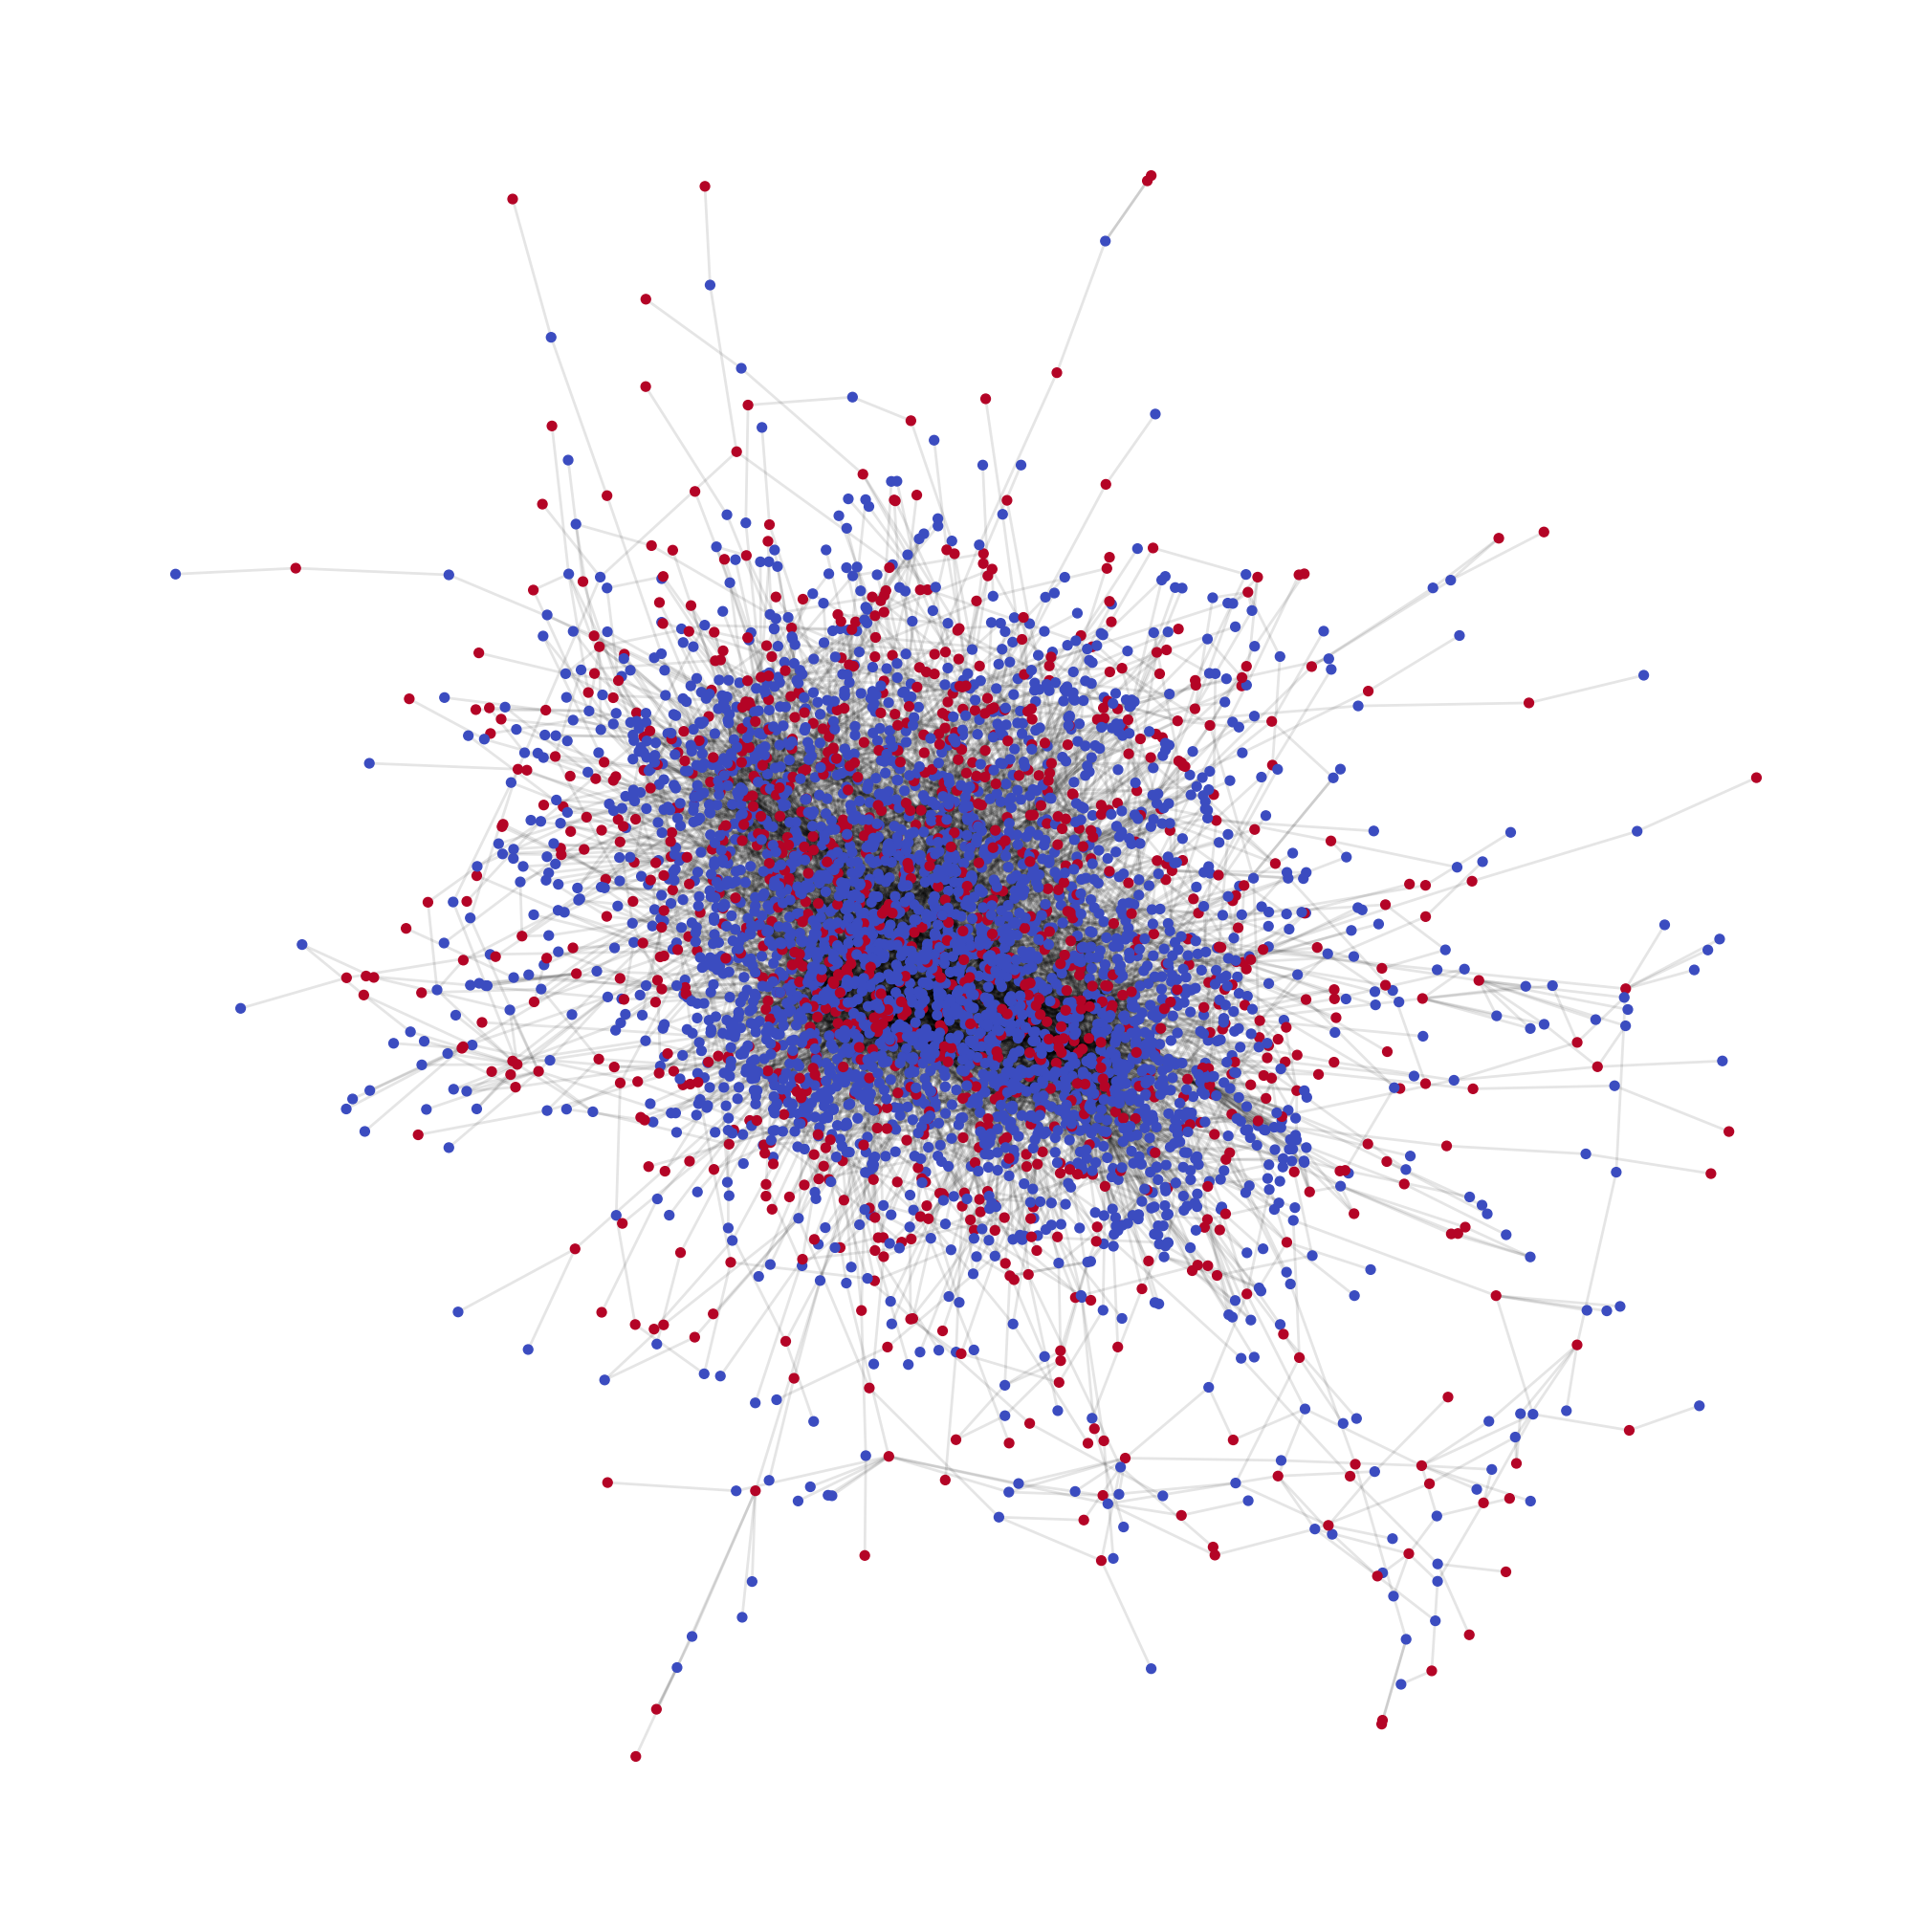

In [64]:
# Graph the large subgraph
color_map = {"playlist": 0, "track": 1}
node_color = [color_map[attr["node_type"]] for (id, attr) in sub_G_lg.nodes(data=True)]
plt.figure(figsize=(20,20))
nx.draw(sub_G_lg,
        cmap=plt.get_cmap('coolwarm'),
        node_color=node_color,
        node_size = 50,
        width = 2,
        edge_color=(0, 0, 0, 0.1))

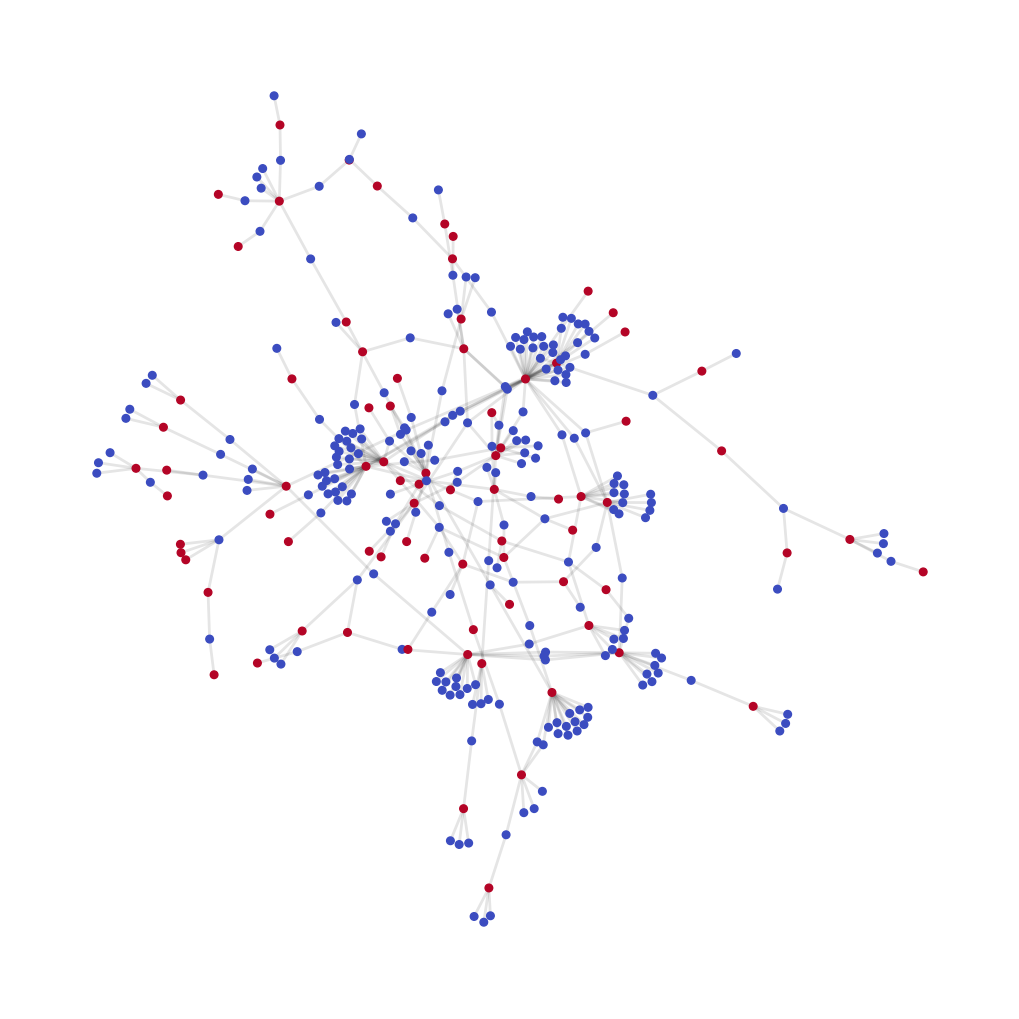

In [71]:
# Graph the subgraph of the small subgraph
color_map = {"playlist": 0, "track": 1}
node_color = [color_map[attr["node_type"]] for (id, attr) in sub_G_sm.nodes(data=True)]
plt.figure(figsize=(10,10))
nx.draw(sub_G_sm,
        cmap=plt.get_cmap('coolwarm'),
        node_color=node_color,
        node_size = 30,
        width = 2,
        edge_color=(0, 0, 0, 0.1))

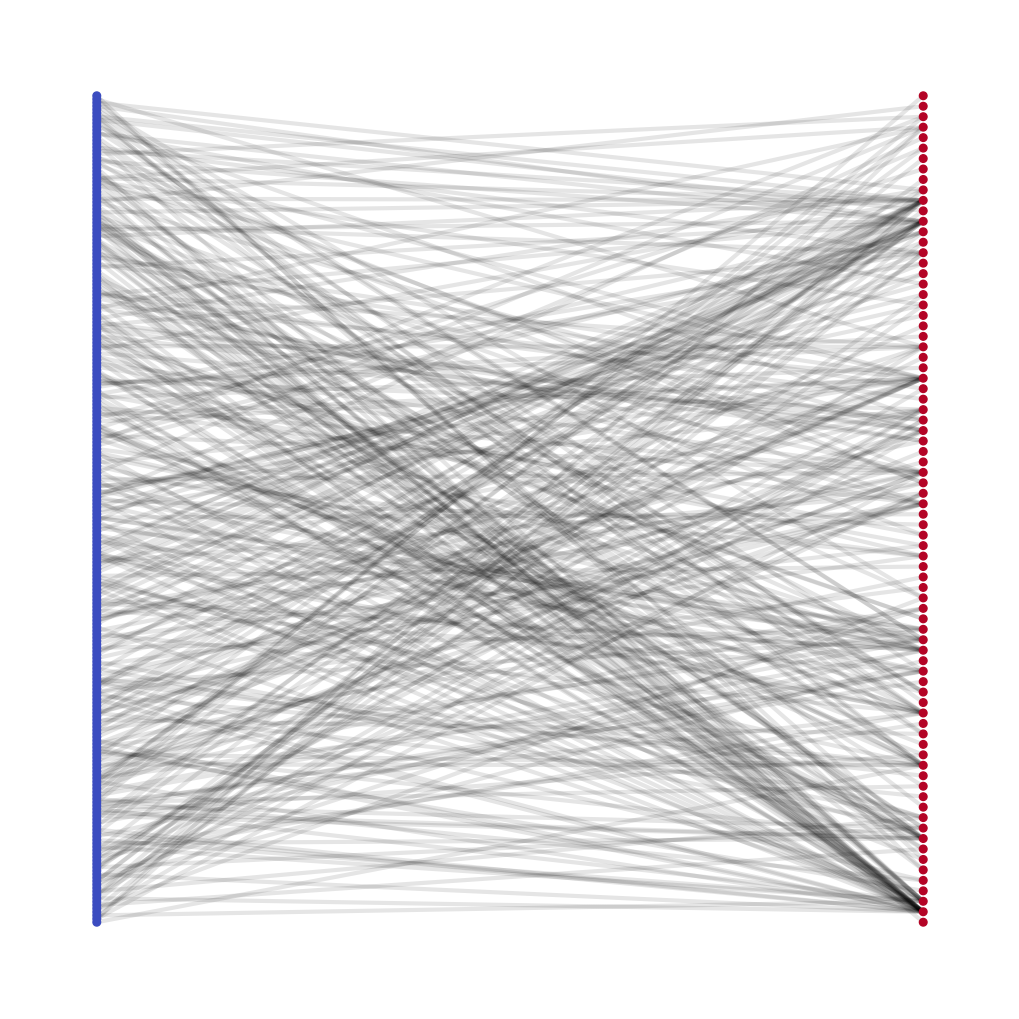

In [72]:
# Show the smaller subgraph as bipartite
top = nx.bipartite.sets(sub_G_sm)[0]
pos = nx.bipartite_layout(sub_G_sm, top)
plt.figure(figsize=(10,10))
nx.draw(sub_G_sm,
        pos=pos,
        cmap=plt.get_cmap('coolwarm'),
        node_color=node_color,
        node_size = 30,
        width = 3,
        edge_color=(0, 0, 0, 0.1))

## Constructing a graph dataset

In [4]:
# Note if you've already generated the graph above, you can skip those steps, and simply run set reload to True!
reload = True
if reload:
  G = pickle.load(open("30core_first_200.pkl", "rb"))
print('Num nodes:', G.number_of_nodes(), '. Num edges:', G.number_of_edges())

Num nodes: 149709 . Num edges: 8253574


In [5]:
n_nodes, n_edges = G.number_of_nodes(), G.number_of_edges()

# by sorting them we get an ordering playlist1, ..., playlistN, track1, ..., trackN
sorted_nodes = sorted(list(G.nodes()))

# create dictionaries to index to 0 to n_nodes, will be necessary for when we are using tensors
node2id = dict(zip(sorted_nodes, np.arange(n_nodes)))
id2node = dict(zip(np.arange(n_nodes), sorted_nodes))

G = nx.relabel_nodes(G, node2id)

# also keep track of how many playlists, tracks we have
playlists_idx = [i for i, v in enumerate(node2id.keys()) if "playlist" in v]
tracks_idx = [i for i, v in enumerate(node2id.keys()) if "track" in v]

n_playlists = np.max(playlists_idx) + 1
n_tracks = n_nodes - n_playlists

n_playlists, n_tracks

(108697, 41012)

## Train-Val-Test Split

- Train set (70%) - train the model
- Validation set (15%) - tune model's hyperparams and prevent overfitting
- Test set (15%) - evaluate model's performance on unseen data

Splitting the graph can be done using PyG method `RandomLinkSplit` which randomly removes a specified percentage of edges in the graph. The split is performed such that the training split does not include edges in the validation and test splits, and the validation split does not include edges in the test split.

We set add_negative_train_samples and neg_sampling ratio to zero as we will be implementing our own.

In [6]:
# turn the graph into a torch_geometric Data object

num_nodes = n_nodes
edge_idx = torch.Tensor(np.array(G.edges()).T)
graph_data = Data(edge_index = edge_idx, num_nodes = num_nodes)

# train/val/test splits
transform = RandomLinkSplit(
    is_undirected=True,
    add_negative_train_samples=False,
    neg_sampling_ratio=0,
    num_val=0.15, num_test=0.15
)

train_split, val_split, test_split = transform(graph_data)

In [15]:
print(train_split)
print(val_split)
print(test_split)

Data(edge_index=[2, 5771334], num_nodes=149709, edge_label=[2885667], edge_label_index=[2, 2885667])
Data(edge_index=[2, 5771334], num_nodes=149709, edge_label=[618356], edge_label_index=[2, 618356])
Data(edge_index=[2, 7008046], num_nodes=149709, edge_label=[618356], edge_label_index=[2, 618356])


From this split, we obtain two types of edges: 
- `edge_index` - message-passing edges - propagate information
- `edge_label_index` - supervision edges - supervise training process, indicating the presence or absence of playlist-track link (edges we wish to predict)

In [12]:
# note these are stored as float32, we need them to be int64 for future training

# Edge index: message passing edges
train_split.edge_index = train_split.edge_index.type(torch.int64)
val_split.edge_index = val_split.edge_index.type(torch.int64)
test_split.edge_index = test_split.edge_index.type(torch.int64)

# Edge label index: supervision edges
train_split.edge_label_index = train_split.edge_label_index.type(torch.int64)
val_split.edge_label_index = val_split.edge_label_index.type(torch.int64)
test_split.edge_label_index = test_split.edge_label_index.type(torch.int64)

print(f"Train set has {train_split.edge_label_index.shape[1]} positives upervision edges")
print(f"Validation set has {val_split.edge_label_index.shape[1]} positive supervision edges")
print(f"Test set has {test_split.edge_label_index.shape[1]} positive supervision edges")
print()

print(f"Train set has {train_split.edge_index.shape[1]} message passing edges")
print(f"Validation set has {val_split.edge_index.shape[1]} message passing edges")
print(f"Test set has {test_split.edge_index.shape[1]} message passing edges")

Train set has 2885667 positives upervision edges
Validation set has 618356 positive supervision edges
Test set has 618356 positive supervision edges

Train set has 5771334 message passing edges
Validation set has 5771334 message passing edges
Test set has 7008046 message passing edges
